# IP Utilization of Anycast Prefixes

How many IPs within anycast /24-prefixes are actually active?
Which ASes have high or low utilization, and how does this relate to HRP (Highly Responsive Prefix) status?

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime

import sys
sys.path.append(str(Path.cwd().parent))
sys.path.append(str(Path.cwd().parent.parent))
from add_ASN import CaidaASLookup
import census_helper

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

plt.style.use('default')
plt.rcParams['axes.labelsize'] = 20
plt.rcParams.update({'font.size': 14})

ts = datetime(2026, 2, 18)

## Data Loading

In [2]:
census_v4 = census_helper.download_date(ts, 'v4')
census_v4 = census_v4[census_v4['GCD_ICMPv4'] > 1]

hrp = pd.read_csv('part-00000-221fd490-deca-4171-ad09-7cf2764b8c5b-c000.csv')
hrp = hrp[hrp['is_hrp']]
census_v4['is_hrp'] = census_v4['prefix'].isin(hrp['prefix'])

print(f"{census_v4['prefix'].nunique():,} /24-prefixes, "
      f"{census_v4[census_v4['is_hrp']]['prefix'].nunique():,} are HRP")

14,346 /24-prefixes, 9,713 are HRP


In [3]:
ip_services = pd.read_csv('part-00000-a6158df2-c124-48da-814d-c180043134fa-c000.csv')
ip_services['/24'] = (
    ip_services['ip'].str.split('.').str[:3].str.join('.') + '.0/24'
)

ip_counts = ip_services.groupby('/24').size()

census_v4['number_of_active_ips'] = (
    census_v4['prefix'].map(ip_counts).fillna(0).astype(int)
)
census_v4['ip_utilization'] = census_v4['number_of_active_ips'] / 256

print(f"{ip_services['ip'].nunique():,} unique active IPs across "
      f"{ip_services['/24'].nunique():,} /24-prefixes")

1,769,803 unique active IPs across 13,233 /24-prefixes


## IP Utilization per AS

In [4]:
census_v4_exploded = census_v4.assign(ASN=census_v4['ASN'].str.split('_')).explode('ASN')

asn_table = (
    census_v4_exploded
    .groupby('ASN')
    .agg(
        active_ips=('number_of_active_ips', 'sum'),
        hrp_count=('is_hrp', 'sum'),
        slash24s=('prefix', 'count'),
    )
)

asn_table['IP Utilization'] = asn_table['active_ips'] / (asn_table['slash24s'] * 256)
asn_table['HRP'] = asn_table['hrp_count'] / asn_table['slash24s']
asn_table = asn_table.drop(columns='hrp_count').reset_index()
asn_table = asn_table.sort_values('active_ips', ascending=False)

asn_table.head(10)

,ASN,active_ips,slash24s,IP Utilization,HRP
64,13335,657528,2866,0.896186,0.989184
666,396982,491593,4298,0.446786,0.973476
915,54113,209398,827,0.989070,0.990326
158,16509,133371,1603,0.325003,0.259513
322,209242,59549,270,0.861531,0.966667
749,40509,22113,223,0.387349,1.000000
695,398787,16383,64,0.999939,1.000000
97,139341,12997,118,0.430250,0.805085
31,12008,11514,98,0.458945,0.448980
154,15967,11173,195,0.223818,0.958974


In [5]:
latex_table = asn_table.sort_values('active_ips', ascending=False).head(10).to_latex(
    index=False, float_format='%.3f'
)
print(latex_table)

\begin{tabular}{lrrrr}
\toprule
ASN & active_ips & slash24s & IP Utilization & HRP \\
\midrule
13335 & 657528 & 2866 & 0.896 & 0.989 \\
396982 & 491593 & 4298 & 0.447 & 0.973 \\
54113 & 209398 & 827 & 0.989 & 0.990 \\
16509 & 133371 & 1603 & 0.325 & 0.260 \\
209242 & 59549 & 270 & 0.862 & 0.967 \\
40509 & 22113 & 223 & 0.387 & 1.000 \\
398787 & 16383 & 64 & 1.000 & 1.000 \\
139341 & 12997 & 118 & 0.430 & 0.805 \\
12008 & 11514 & 98 & 0.459 & 0.449 \\
15967 & 11173 & 195 & 0.224 & 0.959 \\
\bottomrule
\end{tabular}



## AS Counts (IPv4 + IPv6)

In [6]:
all_asns_v4 = census_v4['ASN'].str.split('_').explode()

census_v6 = census_helper.download_date(ts, 'v6')
census_v6 = census_v6[census_v6['GCD_ICMPv6'] > 1]

all_asns_v6 = census_v6['ASN'].str.split('_').explode()

all_unique = pd.concat([all_asns_v4, all_asns_v6]).unique()
overlap = set(all_asns_v4) & set(all_asns_v6)

print(f'IPv4 ASes: {all_asns_v4.nunique():,}')
print(f'IPv6 ASes: {all_asns_v6.nunique():,}')
print(f'Combined:  {len(all_unique):,}')
print(f'Overlap:   {len(overlap):,}')
print(f'IPv6 /48-prefixes: {census_v6["prefix"].nunique():,}')

IPv4 ASes: 1,075
IPv6 ASes: 579
Combined:  1,223
Overlap:   431
IPv6 /48-prefixes: 13,007


In [7]:
import requests

AS_NAME_OVERRIDES = {
    '13335': 'Cloudflare', '15169': 'Google', '20940': 'Akamai',
    '16509': 'AWS', '32934': 'Meta', '8075': 'Microsoft',
}

def get_as_name(asn):
    asn = str(asn).strip()
    if asn in AS_NAME_OVERRIDES:
        return AS_NAME_OVERRIDES[asn]
    try:
        r = requests.get(f'https://stat.ripe.net/data/as-names/data.json?resource=AS{asn}', timeout=5)
        names = r.json()['data']['names']
        name = names.get(f'AS{asn}') or names.get(asn) or asn
        return name if len(name) <= 20 else name[:18] + '..'
    except:
        return f'AS{asn}'

top10_v6 = (
    census_v6.groupby('ASN')['prefix'].nunique()
    .sort_values(ascending=False).head(10)
    .reset_index().rename(columns={'prefix': 'num_prefixes'})
)

total_v6_pfx = census_v6['prefix'].nunique()

rows = ''
for _, row in top10_v6.iterrows():
    asn = str(row['ASN']).strip()
    name = get_as_name(asn)
    n = row['num_prefixes']
    pct = round(n / total_v6_pfx * 100, 1)
    rows += f'        {name} ({asn}) & \\num{{{n}}} & ({pct}\\%) \\\\\n'

latex = f"""\\begin{{table}}[tb]
    \\begin{{tabular}}{{l r@{{~}}l}}
        \\toprule
        Org (ASN) & \\multicolumn{{2}}{{c}}{{/48-Prefixes}} \\\\
        \\midrule
{rows}        \\bottomrule
    \\end{{tabular}}
    \\caption{{Top 10 ASes by number of anycast IPv6 /48-prefixes (n=\\num{{{total_v6_pfx}}}).}}
    \\label{{tab:top_ases_v6}}
\\end{{table}}"""

print(latex)

\begin{table}[tb]
    \begin{tabular}{l r@{~}l}
        \toprule
        Org (ASN) & \multicolumn{2}{c}{/48-Prefixes} \\
        \midrule
        CLOUDFLARESPECTRUM.. (209242) & \num{6421} & (49.4\%) \\
        WEN-NET RUNNAN WEN (214040) & \num{1795} & (13.8\%) \\
        FASTLY - Fastly, I.. (54113) & \num{760} & (5.8\%) \\
        Cloudflare (13335) & \num{620} & (4.8\%) \\
        INCAPSULA - Incaps.. (19551) & \num{587} & (4.5\%) \\
        AKAMAI-AMS Akamai .. (33905) & \num{409} & (3.1\%) \\
        AS-AFILIAS1 - Afil.. (12041) & \num{228} & (1.8\%) \\
        AWS (16509) & \num{186} & (1.4\%) \\
        GODADDY-DNS Host E.. (44273) & \num{124} & (1.0\%) \\
        AS399153_399155_399164_399161_399169_399170 (399153_399155_399164_399161_399169_399170) & \num{108} & (0.8\%) \\
        \bottomrule
    \end{tabular}
    \caption{Top 10 ASes by number of anycast IPv6 /48-prefixes (n=\num{13007}).}
    \label{tab:top_ases_v6}
\end{table}


## IP Utilization and HRP Distribution

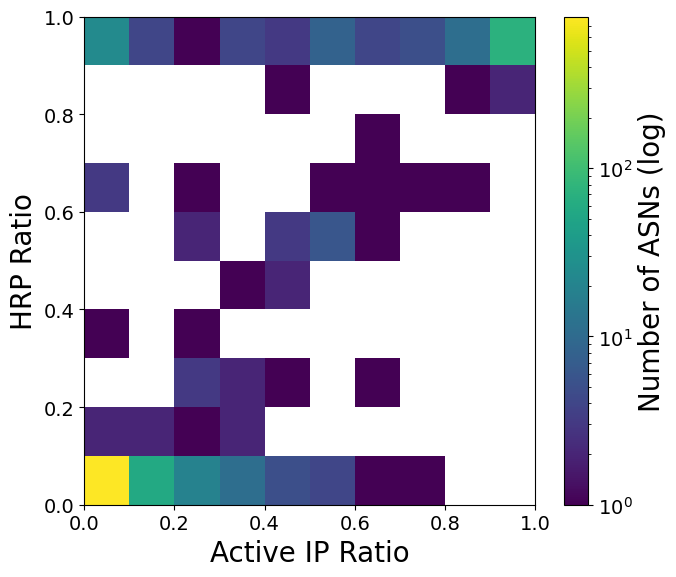

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))

x_bins = np.linspace(0, 1, 11)
y_bins = np.linspace(0, 1, 11)
hist = ax.hist2d(asn_table['IP Utilization'], asn_table['HRP'], bins=[x_bins, y_bins], norm=LogNorm())
ax.set_xlabel('Active IP Ratio')
ax.set_ylabel('HRP Ratio')
fig.colorbar(hist[3], ax=ax).set_label('Number of ASNs (log)')

plt.tight_layout()
plt.savefig('ip_utilization.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

In [9]:
high_util = asn_table[asn_table['IP Utilization'] > 0.66]
low_util  = asn_table[asn_table['IP Utilization'] <= 0.33]

print(f'High utilization (>66%): {len(high_util)} ASes')
print(f'Low utilization  (<=33%): {len(low_util)} ASes')
print(f'Low util + high HRP: {len(asn_table[(asn_table["IP Utilization"] < 0.33) & (asn_table["HRP"] > 0.66)])} ASes')
print(f'High util + low HRP: {len(asn_table[(asn_table["IP Utilization"] > 0.66) & (asn_table["HRP"] < 0.33)])} ASes')

High utilization (>66%): 97 ASes
Low utilization  (<=33%): 922 ASes
Low util + high HRP: 31 ASes
High util + low HRP: 2 ASes
